In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from math import sqrt

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

cv = KFold(n_splits=5, shuffle=False)
bike_data_raw = pd.read_csv('daily-bike-share.csv')

In [12]:
bike_data_raw['dteday'] = pd.to_datetime(bike_data_raw['dteday'])
bike_data = bike_data_raw.copy()
bike_data.drop(['instant', 'dteday', 'yr'], axis=1, inplace=True)

numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit']
target = 'rentals'

bike_data['difference_temp'] = (bike_data['atemp'] - bike_data['temp'])/bike_data['temp']
bike_data.drop(['atemp'], axis=1, inplace=True)
numeric_features = ['temp', 'difference_temp', 'hum', 'windspeed']

## Model 1: Regresja Liniowa

In [13]:
def metric_printer(y_train_true, y_train_pred, y_test_true, y_test_pred, model_name):
    print(f'=== Model: {model_name} ===')

    # Train Metrics
    r2_train = r2_score(y_train_true, y_train_pred)
    mae_train = mean_absolute_error(y_train_true, y_train_pred)
    mse_train = mean_squared_error(y_train_true, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mape_train = mean_absolute_percentage_error(y_train_true, y_train_pred)

    print('--- Train Metrics ---')
    print(f'R²:   {r2_train:.4f}')
    print(f'MAE:  {mae_train:.2f}')
    print(f'MSE:  {mse_train:.2f}')
    print(f'RMSE: {rmse_train:.2f}')
    print(f'MAPE: {mape_train:.2%}')

    # Test Metrics
    r2_test = r2_score(y_test_true, y_test_pred)
    mae_test = mean_absolute_error(y_test_true, y_test_pred)
    mse_test = mean_squared_error(y_test_true, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(y_test_true, y_test_pred)

    print('\n--- Test Metrics ---')
    print(f'R²:   {r2_test:.4f}')
    print(f'MAE:  {mae_test:.2f}')
    print(f'MSE:  {mse_test:.2f}')
    print(f'RMSE: {rmse_test:.2f}')
    print(f'MAPE: {mape_test:.2%}')
    print('--------------------------------')

In [14]:
X_lr = bike_data[['temp']].copy()
y_lr = bike_data[target].copy()
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, shuffle=False)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

y_predict_train_lr = lr_model.predict(X_train_lr)
y_predict_test_lr  = lr_model.predict(X_test_lr)

metric_printer(y_train_lr, y_predict_train_lr, y_test_lr, y_predict_test_lr, 'Prosta Regresja Liniowa')


=== Model: Prosta Regresja Liniowa ===
--- Train Metrics ---
R²:   0.3062
MAE:  404.83
MSE:  317745.94
RMSE: 563.69
MAPE: 96.69%

--- Test Metrics ---
R²:   0.1941
MAE:  391.03
MSE:  397066.94
RMSE: 630.13
MAPE: 298.65%
--------------------------------


## Model 2: ElasticNet 

In [15]:
X = bike_data[numeric_features + categorical_features].copy()
y = bike_data[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

numeric_transformer = Pipeline(steps=[('logtransformer', PowerTransformer()),('standardscaler', StandardScaler()),('polynomialfeatures', PolynomialFeatures())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),('regressor', ElasticNet(max_iter=10000))])
params = {'preprocessor__num__polynomialfeatures__degree': [1, 2, 3, 4, 5],'regressor__alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0],'regressor__l1_ratio': np.arange(0, 1.1, 0.1)}

final_polynomial_regression_gridsearch = GridSearchCV(final_pipeline, params, scoring='neg_mean_squared_error', cv=cv)
final_polynomial_regression_gridsearch.fit(X_train, y_train)

final_model = final_polynomial_regression_gridsearch.best_estimator_

y_predict_train_final = final_model.predict(X_train)
y_predict_test_final  = final_model.predict(X_test)



In [16]:
metric_printer(y_train, y_predict_train_final, y_test, y_predict_test_final, 'ElasticNet + Regresja Wielomianowa')

=== Model: ElasticNet + Regresja Wielomianowa ===
--- Train Metrics ---
R²:   0.7011
MAE:  261.30
MSE:  136897.75
RMSE: 370.00
MAPE: 74.43%

--- Test Metrics ---
R²:   0.5247
MAE:  348.59
MSE:  234195.93
RMSE: 483.94
MAPE: 85.93%
--------------------------------


## Wizualizacja

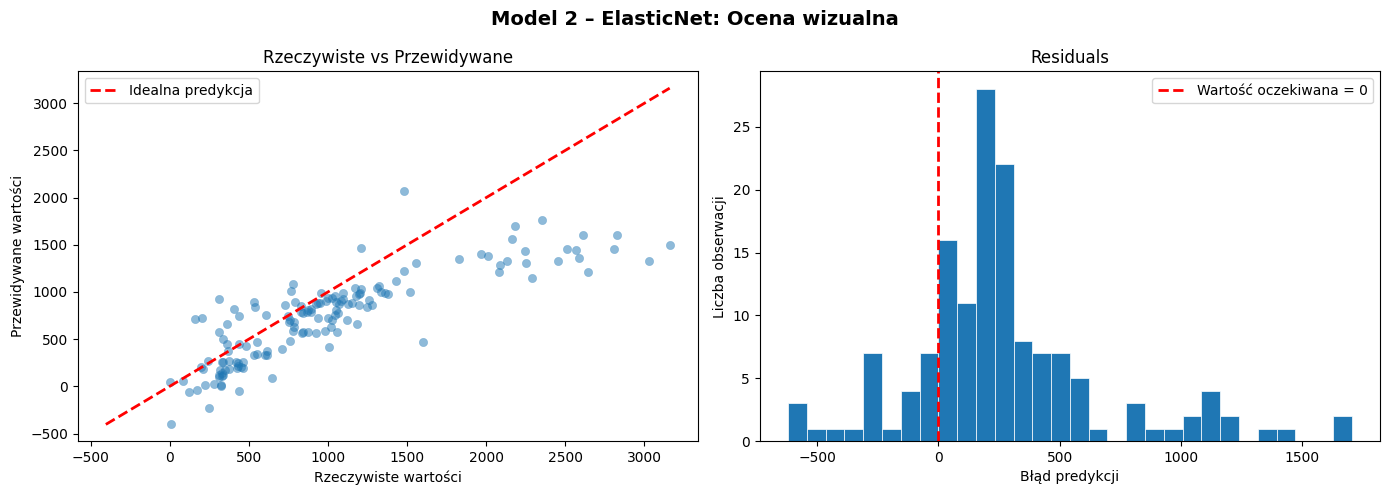

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 2 – ElasticNet: Ocena wizualna', fontsize=14, fontweight='bold')

# Wykres 1
ax = axes[0]
ax.scatter(y_test, y_predict_test_final, alpha=0.5, linewidth=0.3)
min_val = min(y_test.min(), y_predict_test_final.min())
max_val = max(y_test.max(), y_predict_test_final.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Idealna predykcja')
ax.set_xlabel('Rzeczywiste wartości')
ax.set_ylabel('Przewidywane wartości')
ax.set_title('Rzeczywiste vs Przewidywane')
ax.legend()

# Wykres 2
ax = axes[1]
residuals = y_test - y_predict_test_final
ax.hist(residuals, bins=30, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Wartość oczekiwana = 0')

ax.set_xlabel('Błąd predykcji')
ax.set_ylabel('Liczba obserwacji')
ax.set_title('Residuals')
ax.legend()

plt.tight_layout()
plt.show()

## Porównanie Modelu 1 i Modelu 2

In [18]:
# Tabela porównawcza
comparison = pd.DataFrame({
    'Metryka': ['R²', 'MAE', 'MAPE', 'MSE', 'RMSE'],
    'Model 1 – Test  (RegLin)': [
        round(r2_score(y_test_lr, y_predict_test_lr), 4),
        round(mean_absolute_error(y_test_lr, y_predict_test_lr), 2),
        round(mean_absolute_percentage_error(y_test_lr, y_predict_test_lr), 4),
        round(mean_squared_error(y_test_lr, y_predict_test_lr), 2),
        round(sqrt(mean_squared_error(y_test_lr, y_predict_test_lr)), 2)
    ],
    'Model 2 – Test (ElasticNet)': [
        round(r2_score(y_test, y_predict_test_final), 4),
        round(mean_absolute_error(y_test, y_predict_test_final), 2),
        round(mean_absolute_percentage_error(y_test, y_predict_test_final), 4),
        round(mean_squared_error(y_test, y_predict_test_final), 2),
        round(sqrt(mean_squared_error(y_test, y_predict_test_final)), 2)
    ]
})
print(comparison.to_string(index=False))

Metryka  Model 1 – Test  (RegLin)  Model 2 – Test (ElasticNet)
     R²                    0.1941                       0.5247
    MAE                  391.0300                     348.5900
   MAPE                    2.9865                       0.8593
    MSE               397066.9400                  234195.9300
   RMSE                  630.1300                     483.9400


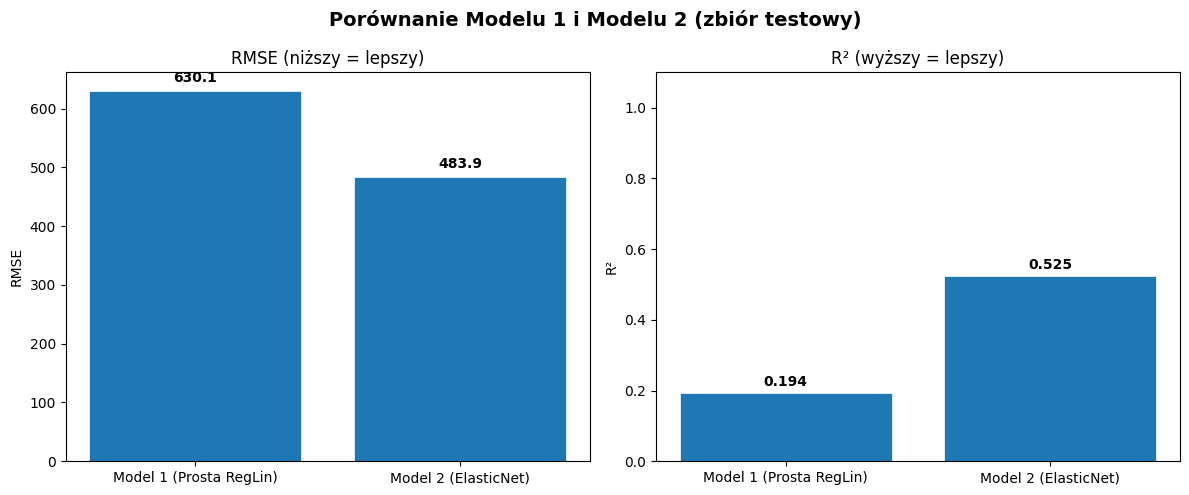

In [19]:


# Porównanie modelów
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Porównanie Modelu 1 i Modelu 2 (zbiór testowy)', fontsize=14, fontweight='bold')

models = ['Model 1 (Prosta RegLin)', 'Model 2 (ElasticNet)']

# wykres  RMSE
rmse_vals = [
    sqrt(mean_squared_error(y_test_lr, y_predict_test_lr)),
    sqrt(mean_squared_error(y_test, y_predict_test_final))
]
bars = axes[0].bar(models, rmse_vals, edgecolor='white', linewidth=0.5)
axes[0].set_title('RMSE (niższy = lepszy)')
axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Wykres R²
r2_vals = [r2_score(y_test_lr, y_predict_test_lr),r2_score(y_test, y_predict_test_final)]

bars2 = axes[1].bar(models, r2_vals, edgecolor='white', linewidth=0.5)
axes[1].set_title('R² (wyższy = lepszy)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.1)

for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()